In [15]:
# We import all the needed packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error as mse
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.api import ExponentialSmoothing

In [16]:
#Import the data
tsa_data = pd.read_csv("../data/tsa-throughput-data-complete.csv")

In [17]:
#We format the data lightly
tsa_data['DateTime'] = pd.to_datetime(tsa_data['DateTime']) #Changing datetime column type
#We want to ignore checkpoints, so we sum over all of the checkpoints at each airport
tsa_airport_data = tsa_data.groupby(["DateTime", "Airport Code", "Airport Name", "City", "State"], as_index=False)["Total Passenger Throughput"].sum()

We will work with data from one airport, Chicago O'Hare International Airport.
We want to test some baseline forecasts for the daily passenger throughput in this airport. We will use the yearly data from 2022 and 2023 to train our model, and use the 2024 as holdout. We want to keep the 2025 data untouched for final testing.

Let's first see a plot of the yearly data.

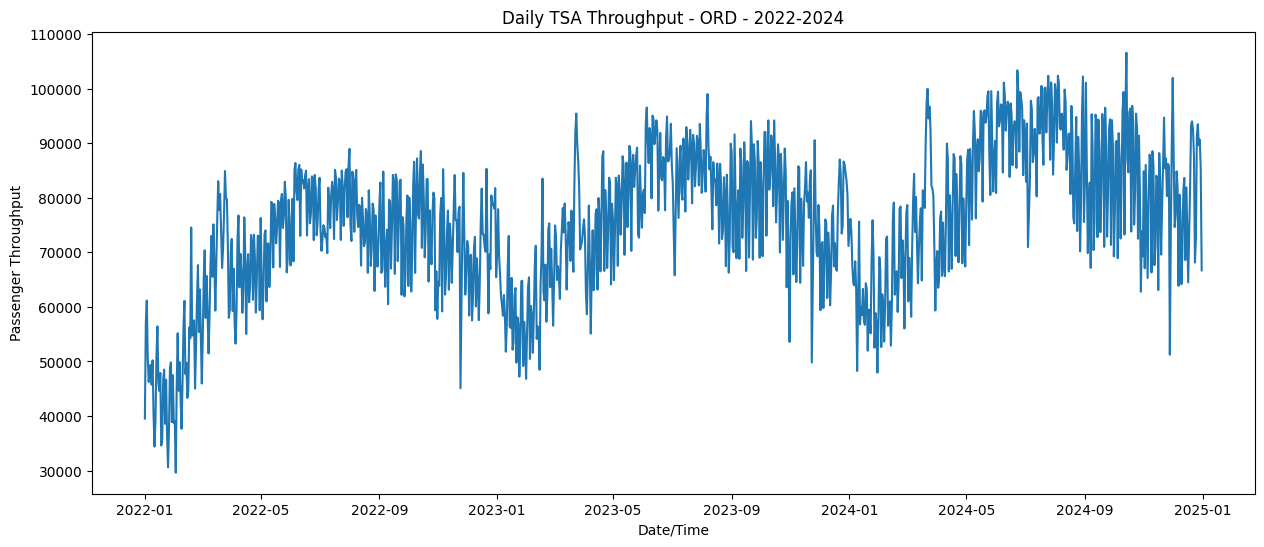

In [18]:

ord_data = tsa_airport_data[tsa_airport_data['Airport Code'] == 'ORD'] #Fixing our airport to be O'Hare

#Let's plot the daily passenger throughput at this airport for the years 2022, 2023, 2024
years=[2022,2023,2024]
ord_data_res=ord_data[ord_data['DateTime'].dt.year.isin(years)]
ord_daily = ord_data_res.groupby(pd.Grouper(key='DateTime', freq='D'))['Total Passenger Throughput'].sum()
plt.figure(figsize=(15, 6))
plt.plot(ord_daily.index, ord_daily)
plt.title('Daily TSA Throughput - ORD - 2022-2024')
plt.xlabel('Date/Time')
plt.ylabel('Passenger Throughput')
plt.show()

As we can observe there is a clear yearly seasonality to this data, and a mild positive trend as we progress from 2022 to 2024.

We see there is yearly seasonality in the data and also a slight upward trend.
We want to generate some baseline predictions. For simplicity let's use the data for 2022 and 2023 as training set and the 2024 data as holdout.

We should note here that 2024 is a leap year, so it has 366 days. This does present a subtlety, but as we are working on baseline forecasts right now, we will simply remove the February 29, 2024 data from the holdout set.

In [19]:
#Selecting the Training Data
ord_data_train=ord_data[ord_data['DateTime'].dt.year.isin([2022,2023])]
ord_daily_train=ord_data_train.groupby(pd.Grouper(key='DateTime', freq='D'))['Total Passenger Throughput'].sum()
#Selecting the Holdout Data
ord_data_ho=ord_data[ord_data['DateTime'].dt.year==2024]
ord_daily_ho=ord_data_ho.groupby(pd.Grouper(key='DateTime', freq='D'))['Total Passenger Throughput'].sum()
ord_daily_ho=ord_daily_ho.drop('2024-02-29')
print('Training Data')
print(ord_daily_train)
print("")
print('Holdout Data')
print(ord_daily_ho)

Training Data
DateTime
2022-01-01    39533
2022-01-02    57237
2022-01-03    61147
2022-01-04    50709
2022-01-05    46234
              ...  
2023-12-27    86115
2023-12-28    84578
2023-12-29    83137
2023-12-30    80535
2023-12-31    71150
Freq: D, Name: Total Passenger Throughput, Length: 730, dtype: int64

Holdout Data
DateTime
2024-01-01    73564
2024-01-02    76130
2024-01-03    73883
2024-01-04    67655
2024-01-05    64342
              ...  
2024-12-27    93459
2024-12-28    89595
2024-12-29    90659
2024-12-30    85391
2024-12-31    66692
Name: Total Passenger Throughput, Length: 365, dtype: int64


We will use two baseline models - a naive seasonal forecast with drift (which was covered in the problem sessions) and triple exponential smoothing.
As we are working with only three years of data, we use a simple timeseries, without cross validation. 

In [20]:
#Defining code for Naive Seasonal With Drift (nswd)
class NaiveSeasonalWithDrift:
    def __init__(self, season_length):
        self.season_length = season_length
        self.deltas = None
        self.last_value = None
    def fit(self, ts):
        if isinstance(ts, pd.Series):
            ts = ts.values
        s = self.season_length
        if len(ts) < s + 1:
            raise ValueError("Need more data than one season")
        self.deltas = ts[-s:] - ts[-s-1:-1]
        self.last_value = ts[-1]

    def forecast(self, h):
        s = self.season_length
        forecasts = np.zeros(h)
        forecasts[0] = self.last_value + self.deltas[0]
        for i in range(1, h):
            forecasts[i] = forecasts[i-1]+self.deltas[i%s]
        return forecasts

Time for some predictions!

In [21]:
#Calling nswd
nswd_test = NaiveSeasonalWithDrift(season_length=365)
nswd_test.fit(ord_daily_train)
nswd_forecast=nswd_test.forecast(365)

#Calling Exponential Smoothing
seasonal_exp_smoothing = ExponentialSmoothing(
    ord_daily_train,
    trend="add",              # additive trend to capture linear slope
    seasonal="add",           # additive seasonality if amplitude is constant
    seasonal_periods=365,      # yearly seasonality
    initialization_method="estimated" 
).fit()
es_forecast = seasonal_exp_smoothing.forecast(steps=365)


In [28]:
print("Dates around day 60:", ord_daily_ho.index[58:63])
print("Actuals around day 60:", ord_daily_ho[58:63])
print("Predictions around day 60:", nswd_forecast[58:63])

Dates around day 60: DatetimeIndex(['2024-02-28', '2024-03-01', '2024-03-02', '2024-03-03',
               '2024-03-04'],
              dtype='datetime64[us]', name='DateTime', freq=None)
Actuals around day 60: DateTime
2024-02-28    69161
2024-03-01    78652
2024-03-02    61015
2024-03-03    68999
2024-03-04    64304
Name: Total Passenger Throughput, dtype: int64
Predictions around day 60: [62262. 70359. 80641. 78677. 70628.]


Let's plot how the two baseline models fared with the holdout data.

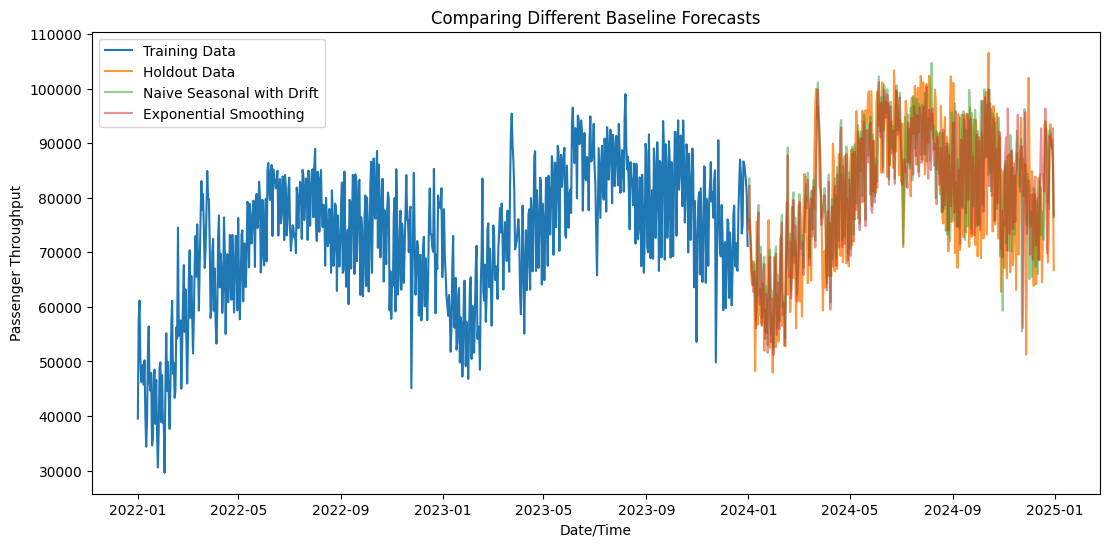

In [22]:
#Plotting the data
plt.figure(figsize=(13, 6))
plt.plot(ord_daily_train.index,ord_daily_train, label='Training Data')
plt.plot(ord_daily_ho.index,ord_daily_ho, label='Holdout Data', alpha=0.8)
plt.plot(ord_daily_ho.index,nswd_forecast, label="Naive Seasonal with Drift",alpha=0.5)
plt.plot(ord_daily_ho.index,es_forecast, label="Exponential Smoothing",alpha=0.5)
plt.title('Comparing Different Baseline Forecasts')
plt.xlabel('Date/Time')
plt.ylabel('Passenger Throughput')
plt.legend()
plt.show()

We can zoom into the section with just the 2024 data to better visualize how close the predictions were.

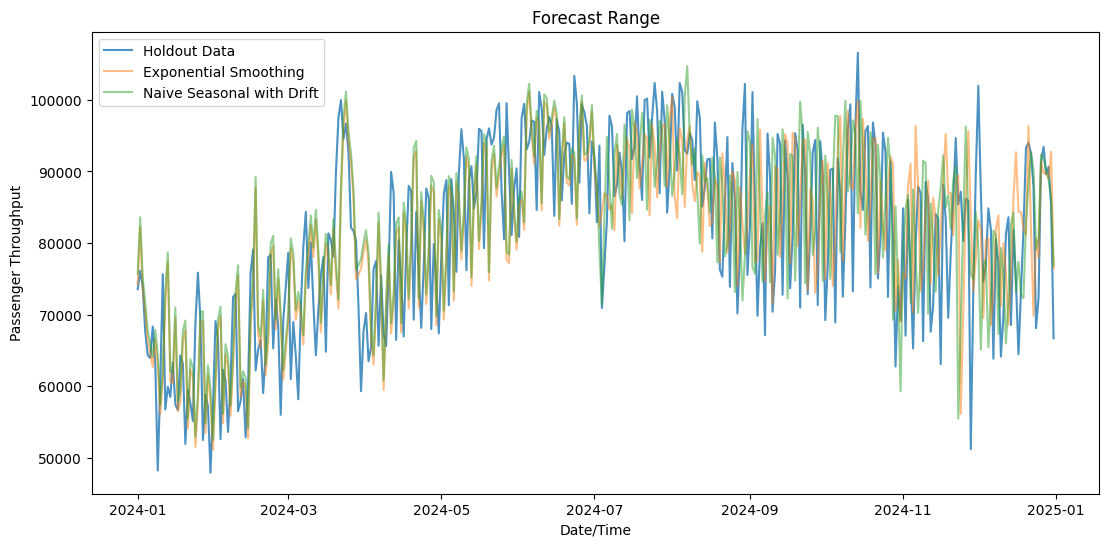

In [23]:
#Let's visualize only the holdout data and exp smoothing
plt.figure(figsize=(13, 6))
plt.plot(ord_daily_ho.index,ord_daily_ho, label='Holdout Data',alpha=0.8)
plt.plot(ord_daily_ho.index,es_forecast, label="Exponential Smoothing",alpha=0.5)
plt.plot(ord_daily_ho.index,nswd_forecast, label="Naive Seasonal with Drift",alpha=0.5)
plt.title('Forecast Range')
plt.xlabel('Date/Time')
plt.ylabel('Passenger Throughput')
plt.legend()
plt.show()

We use root mean squared error to measure the error in the predictions.

In [24]:
#Computing RMSEs
from sklearn.metrics import root_mean_squared_error as rmse

nswd_rmse = mse(ord_daily_ho, nswd_forecast) #computing rmse for nswd model
es_rmse=rmse(ord_daily_ho, es_forecast) #computing rmse for exponential smoothing
rmse={'nswd':nswd_rmse,'es':es_rmse}
rmse

{'nswd': 143571876.3178082, 'es': 10070.249095947614}

This shows that the naive seasonal with drift forecast is performing a bit better than exponential smoothing. 